In [13]:
import xml.etree.ElementTree as ET
import pandas as pd
from pathlib import Path
from tqdm import tqdm

NS = "http://www.nih.gov"
XML_DIR  = Path(r"C:\lidc_data\xml")
META_DIR = Path(r"C:\lidc_data\metadata")


def parse_xml(xml_path):
    try:
        root = ET.parse(xml_path).getroot()
    except ET.ParseError:
        return None, []

    series_elem = root.find(f".//{{{NS}}}SeriesInstanceUid")
    series_uid  = series_elem.text.strip() if series_elem is not None else None
    if series_uid is None:
        return None, []

    nodulos = []
    for sessao_idx, sessao in enumerate(root.iter(f"{{{NS}}}readingSession")):
        for nodulo in sessao.iter(f"{{{NS}}}unblindedReadNodule"):
            chars = nodulo.find(f"{{{NS}}}characteristics")
            if chars is None:
                continue
            mal_elem = chars.find(f"{{{NS}}}malignancy")
            if mal_elem is None or mal_elem.text is None:
                continue
            try:
                score = int(mal_elem.text.strip())
            except ValueError:
                continue

            sop_uids = set()
            xs, ys, zs = [], [], []
            for roi in nodulo.iter(f"{{{NS}}}roi"):
                sop_elem = roi.find(f"{{{NS}}}imageSOP_UID")
                if sop_elem is not None and sop_elem.text:
                    sop_uids.add(sop_elem.text.strip())
                z_elem = roi.find(f"{{{NS}}}imageZposition")
                if z_elem is not None:
                    zs.append(float(z_elem.text))
                for edge in roi.iter(f"{{{NS}}}edgeMap"):
                    x = edge.find(f"{{{NS}}}xCoord")
                    y = edge.find(f"{{{NS}}}yCoord")
                    if x is not None and y is not None:
                        xs.append(float(x.text))
                        ys.append(float(y.text))

            if not sop_uids or not xs:
                continue

            nodulos.append({
                "sessao_idx": sessao_idx,   # NOVO: qual radiologista
                "sop_uids":   sop_uids,
                "score":      score,
                "cx":         sum(xs) / len(xs),
                "cy":         sum(ys) / len(ys),
                "cz":         sum(zs) / len(zs) if zs else None,
            })

    return series_uid, nodulos


def agrupar_por_sop_uid(nodulos):
    """
    Agrupa nódulos que compartilham SOP_UID, mas com restrição extra:
    NUNCA agrupa duas anotações da mesma sessão (radiologista).
    Isso evita o efeito cascata em nódulos grandes/múltiplos.
    """
    n = len(nodulos)
    used = [False] * n
    clusters = []

    for i in range(n):
        if used[i]:
            continue
        cluster = [i]
        used[i] = True
        sessoes_no_cluster = {nodulos[i]["sessao_idx"]}

        changed = True
        while changed:
            changed = False
            for j in range(n):
                if used[j]:
                    continue
                if nodulos[j]["sessao_idx"] in sessoes_no_cluster:
                    continue  # já tem anotação dessa sessão no cluster — bloqueia
                # verifica sobreposição de SOP_UID com QUALQUER membro do cluster
                sobrepoe = any(
                    nodulos[j]["sop_uids"] & nodulos[k]["sop_uids"]
                    for k in cluster
                )
                if sobrepoe:
                    cluster.append(j)
                    used[j] = True
                    sessoes_no_cluster.add(nodulos[j]["sessao_idx"])
                    changed = True
        clusters.append(cluster)

    return clusters


def aplicar_consenso(scores):
    votos = [0 if s in (1, 2) else 1 if s in (4, 5) else None for s in scores]
    votos = [v for v in votos if v is not None]
    if sum(votos) >= 3:
        return 1
    elif (len(votos) - sum(votos)) >= 3:
        return 0
    return None


def construir_dataset():
    cache = META_DIR / "nodulos_consenso_v3.csv"
    xmls  = list(XML_DIR.rglob("*.xml"))
    print(f"Parseando {len(xmls)} XMLs...")

    registros = []
    for xml_path in tqdm(xmls):
        series_uid, nodulos = parse_xml(xml_path)
        if not nodulos:
            continue

        clusters = agrupar_por_sop_uid(nodulos)

        for cluster_ids in clusters:
            cluster = [nodulos[i] for i in cluster_ids]
            scores  = [n["score"] for n in cluster]
            rotulo  = aplicar_consenso(scores)

            registros.append({
                "series_uid":  series_uid,
                "xml_file":    xml_path.name,
                "n_anotacoes": len(cluster),
                "scores":      str(scores),
                "rotulo":      rotulo,
                "cx":          round(sum(n["cx"] for n in cluster) / len(cluster), 2),
                "cy":          round(sum(n["cy"] for n in cluster) / len(cluster), 2),
                "cz":          round(sum(n["cz"] for n in cluster if n["cz"] is not None) / len(cluster), 2),
            })

    df = pd.DataFrame(registros)
    total     = len(df)
    aprovados = df["rotulo"].notna().sum()
    malignos  = (df["rotulo"] == 1).sum()
    benignos  = (df["rotulo"] == 0).sum()

    print(f"\n{'='*45}")
    print(f"Total de nódulos encontrados: {total}")
    print(f"Aprovados consenso 3/4:       {aprovados}")
    print(f"  → Malignos  (rotulo=1):     {malignos}")
    print(f"  → Benignos  (rotulo=0):     {benignos}")
    print(f"Descartados:                  {total - aprovados}")
    print(f"\nDistribuição de n_anotacoes (deve ir só até 4!):")
    print(df["n_anotacoes"].value_counts().sort_index())
    print(f"{'='*45}")

    df.to_csv(cache, index=False)
    print(f"\n✓ Salvo em {cache}")
    return df


df = construir_dataset()

Parseando 1319 XMLs...


100%|██████████| 1319/1319 [00:07<00:00, 181.91it/s]



Total de nódulos encontrados: 2726
Aprovados consenso 3/4:       431
  → Malignos  (rotulo=1):     214
  → Benignos  (rotulo=0):     217
Descartados:                  2295

Distribuição de n_anotacoes (deve ir só até 4!):
n_anotacoes
1    798
2    488
3    500
4    940
Name: count, dtype: int64

✓ Salvo em C:\lidc_data\metadata\nodulos_consenso_v3.csv


In [14]:
import pandas as pd
from pathlib import Path

META_DIR = Path(r"C:\lidc_data\metadata")
df = pd.read_csv(META_DIR / "nodulos_consenso_v3.csv")
df = df[df["rotulo"].notna()].reset_index(drop=True)
print(f"Total: {len(df)}")

# pega um nódulo qualquer pra testar
nodulo = df.iloc[10]
print(nodulo)

Total: 431
series_uid     1.3.6.1.4.1.14519.5.2.1.6279.6001.882070241245...
xml_file                                                 102.xml
n_anotacoes                                                    4
scores                                              [5, 5, 5, 3]
rotulo                                                       1.0
cx                                                         364.6
cy                                                        309.73
cz                                                        -47.77
Name: 10, dtype: object


arquivos .dcm encontrados: 127


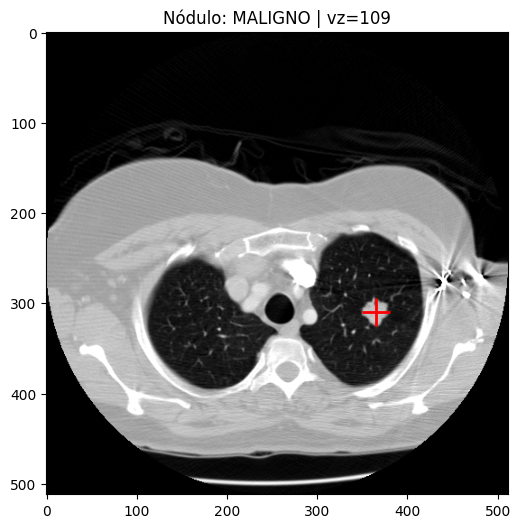

In [16]:
import pydicom
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DICOM_DIR = Path(r"C:\lidc_data\dicom")

series_uid = nodulo["series_uid"]
cx, cy, cz = nodulo["cx"], nodulo["cy"], nodulo["cz"]
rotulo = "MALIGNO" if nodulo["rotulo"] == 1 else "BENIGNO"

serie_dirs = list(DICOM_DIR.rglob(f"*{series_uid}*"))
if not serie_dirs:
    print("⚠ Série não encontrada — provavelmente esse paciente não foi baixado ainda")
else:
    serie_dir = serie_dirs[0]
    dcm_files = sorted(serie_dir.rglob("*.dcm"))
    print(f"arquivos .dcm encontrados: {len(dcm_files)}")

    slices = [pydicom.dcmread(str(f)) for f in dcm_files]
    slices.sort(key=lambda s: float(s.ImagePositionPatient[2]))

    ds0       = slices[0]
    slope     = float(getattr(ds0, "RescaleSlope", 1))
    intercept = float(getattr(ds0, "RescaleIntercept", 0))

    z_positions = [float(s.ImagePositionPatient[2]) for s in slices]
    vz = int(np.argmin([abs(z - cz) for z in z_positions]))

    imagem = slices[vz].pixel_array.astype(np.float32) * slope + intercept
    imagem = np.clip(imagem, -1000, 400)

    vx, vy = int(round(cx)), int(round(cy))

    plt.figure(figsize=(6,6))
    plt.imshow(imagem, cmap="gray")
    plt.plot(vx, vy, "r+", markersize=20, markeredgewidth=2)
    plt.title(f"Nódulo: {rotulo} | vz={vz}")
    plt.savefig(r"C:\lidc_data\metadata\validacao_v3.png", dpi=150)
    plt.show()

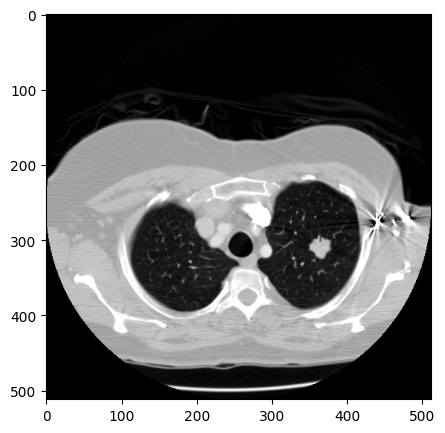

In [39]:
plt.figure(figsize=(5,5))
plt.imshow(imagem, cmap="gray")
plt.show()

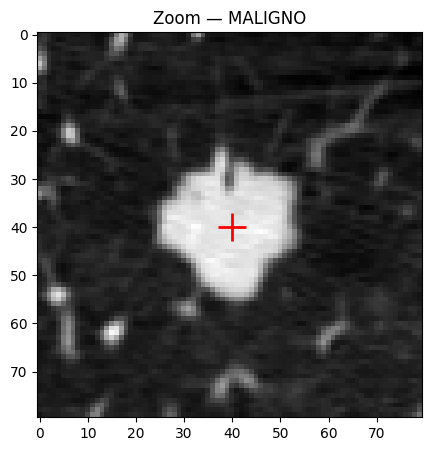

In [17]:
h = 40
y0, y1 = max(0, vy-h), min(512, vy+h)
x0, x1 = max(0, vx-h), min(512, vx+h)

plt.figure(figsize=(5,5))
plt.imshow(imagem[y0:y1, x0:x1], cmap="gray")
plt.plot(vx-x0, vy-y0, "r+", markersize=20, markeredgewidth=2)
plt.title(f"Zoom — {rotulo}")
plt.savefig(r"C:\lidc_data\metadata\validacao_v3_zoom.png", dpi=150)
plt.show()

In [18]:
import pandas as pd
from pathlib import Path

META_DIR = Path(r"C:\lidc_data\metadata")
DICOM_DIR = Path(r"C:\lidc_data\dicom")

df_v3     = pd.read_csv(META_DIR / "nodulos_consenso_v3.csv")
df_series = pd.read_csv(META_DIR / "series_metadata.csv")

series_necessarias_v3 = df_v3[df_v3["rotulo"].notna()]["series_uid"].unique()
df_alvo_v3 = df_series[df_series["SeriesInstanceUID"].isin(series_necessarias_v3)].copy()

print(f"Séries necessárias (v3): {len(series_necessarias_v3)}")
print(f"Pacientes únicos (v3):   {df_alvo_v3['PatientID'].nunique()}")

pacientes_ja_baixados = set(p.name for p in DICOM_DIR.iterdir() if p.is_dir())
pacientes_necessarios_v3 = set(df_alvo_v3["PatientID"])

ja_tenho     = pacientes_necessarios_v3 & pacientes_ja_baixados
falta_baixar = pacientes_necessarios_v3 - pacientes_ja_baixados
sobrando     = pacientes_ja_baixados - pacientes_necessarios_v3

print(f"\nJá tenho (e preciso):  {len(ja_tenho)}")
print(f"Falta baixar:          {len(falta_baixar)}")
print(f"Sobrando (não precisa): {len(sobrando)}")

if "FileSize" in df_alvo_v3.columns:
    df_faltantes = df_alvo_v3[df_alvo_v3["PatientID"].isin(falta_baixar)]
    gb_faltante = df_faltantes["FileSize"].sum() / (1024**3)
    print(f"\nTamanho do que falta baixar: {gb_faltante:.2f} GB")

Séries necessárias (v3): 312
Pacientes únicos (v3):   312

Já tenho (e preciso):  312
Falta baixar:          0
Sobrando (não precisa): 58

Tamanho do que falta baixar: 0.00 GB


In [20]:
import pydicom
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from scipy import ndimage
import gc

META_DIR  = Path(r"C:\lidc_data\metadata")
DICOM_DIR = Path(r"C:\lidc_data\dicom")
PATCH_DIR = Path(r"C:\lidc_data\patches")
PATCH_DIR.mkdir(parents=True, exist_ok=True)

PATCH_SIZE = 32

df = pd.read_csv(META_DIR / "nodulos_consenso_v3.csv")
df = df[df["rotulo"].notna()].reset_index(drop=True)
print(f"Nódulos a processar: {len(df)}")


def carregar_volume(series_dir: Path):
    dcm_files = sorted(series_dir.rglob("*.dcm"))
    if not dcm_files:
        return None, None
    slices = []
    for f in dcm_files:
        try:
            slices.append(pydicom.dcmread(str(f)))
        except Exception:
            continue
    if not slices:
        return None, None
    slices.sort(key=lambda s: float(s.ImagePositionPatient[2]))
    volume = np.stack([s.pixel_array.astype(np.float32) for s in slices])

    ds0       = slices[0]
    slope     = float(getattr(ds0, "RescaleSlope", 1))
    intercept = float(getattr(ds0, "RescaleIntercept", 0))
    volume_hu = volume * slope + intercept

    z_positions = [float(s.ImagePositionPatient[2]) for s in slices]
    spacing_xy  = float(slices[0].PixelSpacing[0])
    meta = {"z_positions": z_positions, "spacing_xy": spacing_xy}

    del slices, volume  # libera memória intermediária
    return volume_hu, meta


def coordenada_para_voxel(cx, cy, cz, meta):
    vx = int(round(cx))
    vy = int(round(cy))
    diffs = [abs(z - cz) for z in meta["z_positions"]]
    vz = int(np.argmin(diffs))
    return vx, vy, vz


def recortar_patch(volume_hu, vx, vy, vz, size=32):
    h = size // 2
    D, H, W = volume_hu.shape
    z0, z1 = max(0, vz-h), min(D, vz+h)
    y0, y1 = max(0, vy-h), min(H, vy+h)
    x0, x1 = max(0, vx-h), min(W, vx+h)
    patch = volume_hu[z0:z1, y0:y1, x0:x1]
    pad = ((h-(vz-z0), h-(z1-vz)), (h-(vy-y0), h-(y1-vy)), (h-(vx-x0), h-(x1-vx)))
    patch = np.pad(patch, pad, mode="constant", constant_values=-1000)
    return patch


def segmentar_nodulo(patch, hu_threshold=-300):
    mascara_densidade = patch > hu_threshold
    labels, n_labels = ndimage.label(mascara_densidade)
    centro = tuple(s // 2 for s in patch.shape)
    label_central = labels[centro]
    if label_central == 0:
        return mascara_densidade
    return labels == label_central


# AGRUPA nódulos por série ANTES de processar — assim cada volume é
# carregado UMA VEZ SÓ e processa todos os nódulos daquele paciente
# antes de descartar o volume da memória.
grupos = df.groupby("series_uid")

erros, salvos = 0, 0
indices = []

for series_uid, grupo in tqdm(grupos, desc="Processando pacientes"):
    serie_dirs = list(DICOM_DIR.rglob(f"*{series_uid}*"))
    if not serie_dirs:
        erros += len(grupo)
        continue

    volume_hu, meta = carregar_volume(serie_dirs[0])
    if volume_hu is None:
        erros += len(grupo)
        continue

    for idx, row in grupo.iterrows():
        rotulo     = int(row["rotulo"])
        cx, cy, cz = row["cx"], row["cy"], row["cz"]

        vx, vy, vz = coordenada_para_voxel(cx, cy, cz, meta)
        patch       = recortar_patch(volume_hu, vx, vy, vz, size=PATCH_SIZE)
        mascara     = segmentar_nodulo(patch)

        nome = f"patch_{idx:04d}_label{rotulo}.npz"
        np.savez_compressed(
            PATCH_DIR / nome,
            patch=patch.astype(np.float32),
            mascara=mascara.astype(np.uint8),
            rotulo=rotulo,
        )
        indices.append({"arquivo": nome, "rotulo": rotulo, "idx_original": idx,
                         "series_uid": series_uid})
        salvos += 1

    # libera o volume da memória antes de ir pro próximo paciente
    del volume_hu
    gc.collect()

df_index = pd.DataFrame(indices)
df_index.to_csv(META_DIR / "patches_index.csv", index=False)

print(f"\n{'='*45}")
print(f"Patches salvos: {salvos}")
print(f"Erros:          {erros}")
print(f"{'='*45}")
print(f"✓ Patches em:  {PATCH_DIR}")
print(f"✓ Índice em:   {META_DIR / 'patches_index.csv'}")

Nódulos a processar: 431


Processando pacientes: 100%|██████████| 312/312 [15:37<00:00,  3.00s/it]


Patches salvos: 431
Erros:          0
✓ Patches em:  C:\lidc_data\patches
✓ Índice em:   C:\lidc_data\metadata\patches_index.csv


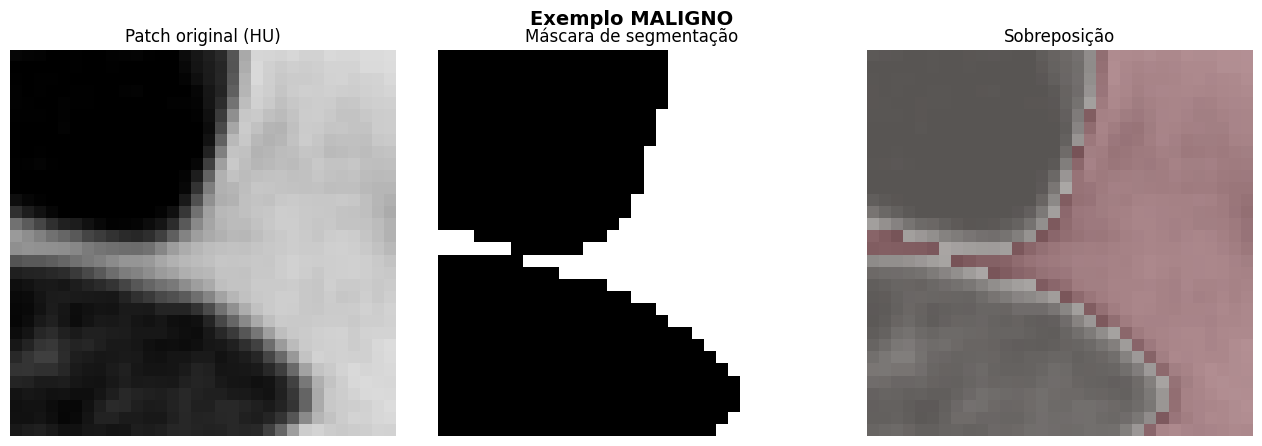

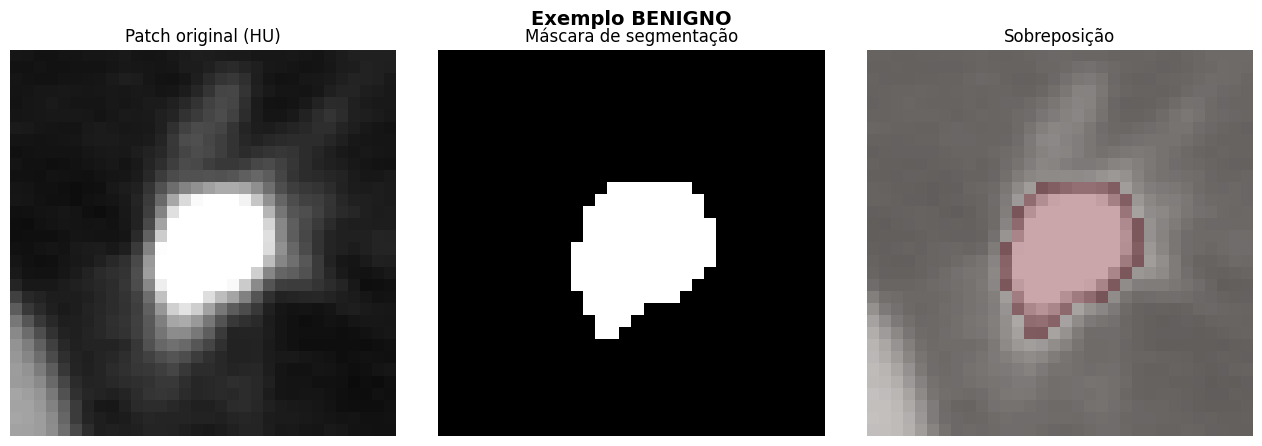

✓ Salvos: exemplo_maligno.png e exemplo_benigno.png


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

PATCH_DIR = Path(r"C:\lidc_data\patches")
META_DIR  = Path(r"C:\lidc_data\metadata")

df_index = pd.read_csv(META_DIR / "patches_index.csv")

# pega um exemplo maligno e um benigno pra comparar
exemplo_maligno = df_index[df_index["rotulo"] == 1].iloc[0]
exemplo_benigno = df_index[df_index["rotulo"] == 0].iloc[0]

def visualizar_patch(arquivo, titulo):
    data = np.load(PATCH_DIR / arquivo)
    patch   = data["patch"]
    mascara = data["mascara"]

    z_central = patch.shape[0] // 2

    fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

    axes[0].imshow(patch[z_central], cmap="gray", vmin=-1000, vmax=400)
    axes[0].set_title("Patch original (HU)")
    axes[0].axis("off")

    axes[1].imshow(mascara[z_central], cmap="gray")
    axes[1].set_title("Máscara de segmentação")
    axes[1].axis("off")

    axes[2].imshow(patch[z_central], cmap="gray", vmin=-1000, vmax=400)
    axes[2].imshow(mascara[z_central], cmap="Reds", alpha=0.35)
    axes[2].set_title("Sobreposição")
    axes[2].axis("off")

    plt.suptitle(titulo, fontsize=14, fontweight="bold")
    plt.tight_layout()
    return fig

fig1 = visualizar_patch(exemplo_maligno["arquivo"], "Exemplo MALIGNO")
fig1.savefig(META_DIR / "exemplo_maligno.png", dpi=150, bbox_inches="tight")

fig2 = visualizar_patch(exemplo_benigno["arquivo"], "Exemplo BENIGNO")
fig2.savefig(META_DIR / "exemplo_benigno.png", dpi=150, bbox_inches="tight")

plt.show()
print("✓ Salvos: exemplo_maligno.png e exemplo_benigno.png")

In [23]:
def segmentar_nodulo_v2(patch, hu_min=-300, hu_max=400, max_fracao=0.4):
    """
    Segmentação com piso E teto de HU (isola tecido mole/nódulo,
    exclui ar e osso/calcificação densa).
    Se o blob central ainda ocupar fração grande demais do patch
    (provável fusão com estrutura vizinha), aplica erosão para
    tentar separar.
    """
    mascara_densidade = (patch > hu_min) & (patch < hu_max)

    labels, _ = ndimage.label(mascara_densidade)
    centro = tuple(s // 2 for s in patch.shape)
    label_central = labels[centro]

    if label_central == 0:
        return mascara_densidade

    mascara = labels == label_central
    fracao = mascara.sum() / mascara.size

    # se a máscara ficou grande demais, tenta erosão pra "quebrar" a
    # conexão com estruturas vizinhas (afina a ponte de conexão)
    tentativas = 0
    while fracao > max_fracao and tentativas < 3:
        mascara_erodida = ndimage.binary_erosion(mascara, iterations=1)
        if mascara_erodida[centro] == 0:
            break  # erosão removeu até o centro, para
        labels2, _ = ndimage.label(mascara_erodida)
        label_central2 = labels2[centro]
        mascara = labels2 == label_central2
        fracao = mascara.sum() / mascara.size
        tentativas += 1

    return mascara

In [24]:
import numpy as np
from scipy import ndimage

casos_problematicos = [
    "patch_0282_label1.npz", "patch_0097_label1.npz", "patch_0327_label1.npz",
    "patch_0200_label1.npz", "patch_0375_label1.npz", "patch_0376_label1.npz",
    "patch_0320_label0.npz", "patch_0300_label0.npz", "patch_0026_label0.npz",
]

for arquivo in casos_problematicos:
    data = np.load(PATCH_DIR / arquivo)
    patch = data["patch"]
    mascara_nova = segmentar_nodulo_v2(patch)
    fracao_nova = mascara_nova.sum() / mascara_nova.size
    print(f"{arquivo}: {fracao_nova*100:.1f}% (era >30-100%)")

patch_0282_label1.npz: 33.4% (era >30-100%)
patch_0097_label1.npz: 29.9% (era >30-100%)
patch_0327_label1.npz: 43.4% (era >30-100%)
patch_0200_label1.npz: 15.2% (era >30-100%)
patch_0375_label1.npz: 49.8% (era >30-100%)
patch_0376_label1.npz: 31.5% (era >30-100%)
patch_0320_label0.npz: 38.1% (era >30-100%)
patch_0300_label0.npz: 44.8% (era >30-100%)
patch_0026_label0.npz: 56.4% (era >30-100%)


In [25]:
import numpy as np

problematicos_v2 = 0
fracoes = []

for i in range(len(df_index)):
    arquivo = df_index.iloc[i]["arquivo"]
    data = np.load(PATCH_DIR / arquivo)
    patch = data["patch"]
    mascara_nova = segmentar_nodulo_v2(patch)
    fracao = mascara_nova.sum() / mascara_nova.size
    fracoes.append(fracao)
    if fracao > 0.4:
        problematicos_v2 += 1

fracoes = np.array(fracoes)
print(f"Total processado: {len(fracoes)}")
print(f"Fração média da máscara: {fracoes.mean()*100:.1f}%")
print(f"Mediana: {np.median(fracoes)*100:.1f}%")
print(f"Problemáticos (>40%): {problematicos_v2} ({problematicos_v2/len(fracoes)*100:.1f}%)")

Total processado: 431
Fração média da máscara: 15.5%
Mediana: 9.2%
Problemáticos (>40%): 26 (6.0%)


In [26]:
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from scipy import ndimage

PATCH_DIR = Path(r"C:\lidc_data\patches")
META_DIR  = Path(r"C:\lidc_data\metadata")
df_index = pd.read_csv(META_DIR / "patches_index.csv")


def segmentar_nodulo_v2(patch, hu_min=-300, hu_max=400, max_fracao=0.4):
    mascara_densidade = (patch > hu_min) & (patch < hu_max)
    labels, _ = ndimage.label(mascara_densidade)
    centro = tuple(s // 2 for s in patch.shape)
    label_central = labels[centro]
    if label_central == 0:
        return mascara_densidade
    mascara = labels == label_central
    fracao = mascara.sum() / mascara.size
    tentativas = 0
    while fracao > max_fracao and tentativas < 3:
        mascara_erodida = ndimage.binary_erosion(mascara, iterations=1)
        if mascara_erodida[centro] == 0:
            break
        labels2, _ = ndimage.label(mascara_erodida)
        label_central2 = labels2[centro]
        mascara = labels2 == label_central2
        fracao = mascara.sum() / mascara.size
        tentativas += 1
    return mascara


print("Reprocessando máscaras com segmentação v2...")
fracoes_finais = []

for i in tqdm(range(len(df_index))):
    arquivo = df_index.iloc[i]["arquivo"]
    caminho = PATCH_DIR / arquivo
    data = np.load(caminho)
    patch  = data["patch"]
    rotulo = data["rotulo"]

    mascara_v2 = segmentar_nodulo_v2(patch)
    fracoes_finais.append(mascara_v2.sum() / mascara_v2.size)

    # sobrescreve o arquivo com a máscara v2 (mantém o patch original)
    np.savez_compressed(caminho, patch=patch, mascara=mascara_v2.astype(np.uint8), rotulo=rotulo)

fracoes_finais = np.array(fracoes_finais)
print(f"\n✓ Reprocessamento concluído")
print(f"Fração média final: {fracoes_finais.mean()*100:.1f}%")
print(f"Problemáticos (>40%): {(fracoes_finais > 0.4).sum()} ({(fracoes_finais > 0.4).mean()*100:.1f}%)")

Reprocessando máscaras com segmentação v2...


100%|██████████| 431/431 [00:09<00:00, 44.68it/s]


✓ Reprocessamento concluído
Fração média final: 15.5%
Problemáticos (>40%): 26 (6.0%)


In [27]:
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from scipy import ndimage
from skimage.feature import graycomatrix, graycoprops

PATCH_DIR = Path(r"C:\lidc_data\patches")
META_DIR  = Path(r"C:\lidc_data\metadata")

df_index = pd.read_csv(META_DIR / "patches_index.csv")
print(f"Nódulos a processar: {len(df_index)}")


# ════════════════════════════════════════════════════════════════
# FEATURES DE SHAPE (usa a máscara, calculadas em 3D)
# ════════════════════════════════════════════════════════════════

def features_shape(mascara):
    """
    Features de forma do nódulo, calculadas em 3D.
    Baseadas no que o artigo usa (área, eccentricidade, circularidade),
    adaptadas para volume.
    """
    volume_voxels = mascara.sum()

    if volume_voxels == 0:
        return {
            "shape_volume": 0, "shape_superficie": 0,
            "shape_esfericidade": 0, "shape_compacidade": 0,
            "shape_extensao_z": 0, "shape_extensao_y": 0, "shape_extensao_x": 0,
        }

    # superfície: voxels da borda (que têm vizinho fora da máscara)
    erodida = ndimage.binary_erosion(mascara)
    borda = mascara & ~erodida
    superficie_voxels = borda.sum()

    # esfericidade: quão "redondo" é o nódulo (1.0 = esfera perfeita)
    # fórmula: pi^(1/3) * (6*V)^(2/3) / A
    if superficie_voxels > 0:
        esfericidade = (np.pi ** (1/3)) * ((6 * volume_voxels) ** (2/3)) / superficie_voxels
    else:
        esfericidade = 0

    # compacidade 3D: volume / volume da esfera que envolve o nódulo
    coords = np.argwhere(mascara)
    extensoes = coords.max(axis=0) - coords.min(axis=0) + 1  # extensão em z, y, x
    raio_equivalente = max(extensoes) / 2
    volume_esfera_envolvente = (4/3) * np.pi * (raio_equivalente ** 3)
    compacidade = volume_voxels / volume_esfera_envolvente if volume_esfera_envolvente > 0 else 0

    return {
        "shape_volume":        int(volume_voxels),
        "shape_superficie":    int(superficie_voxels),
        "shape_esfericidade":  round(float(esfericidade), 4),
        "shape_compacidade":   round(float(compacidade), 4),
        "shape_extensao_z":    int(extensoes[0]),
        "shape_extensao_y":    int(extensoes[1]),
        "shape_extensao_x":    int(extensoes[2]),
    }


# ════════════════════════════════════════════════════════════════
# FEATURES DE TEXTURA GLCM (usa patch + máscara, na fatia central)
# ════════════════════════════════════════════════════════════════

def features_textura_glcm(patch, mascara):
    """
    Features de Haralick via GLCM, calculadas na fatia central do
    patch, considerando só os pixels dentro da máscara do nódulo.
    Mesmas features do artigo: mean, variance, energy, entropy,
    contrast, correlation, homogeneity (IDM).
    """
    z_central = patch.shape[0] // 2
    fatia       = patch[z_central]
    fatia_mask  = mascara[z_central]

    # normaliza HU para 0-255 (uint8) para o GLCM funcionar
    fatia_clip = np.clip(fatia, -1000, 400)
    fatia_norm = ((fatia_clip + 1000) / 1400 * 255).astype(np.uint8)

    # zera pixels fora da máscara (não entram no cálculo de textura)
    fatia_norm_masked = fatia_norm.copy()
    fatia_norm_masked[~fatia_mask] = 0

    if fatia_mask.sum() < 4:  # máscara vazia ou quase — não dá pra calcular GLCM
        return {f"glcm_{p}": 0.0 for p in
                ["mean", "variance", "energy", "entropy", "contrast",
                 "correlation", "homogeneity"]}

    glcm = graycomatrix(
        fatia_norm_masked,
        distances=[1],
        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],  # 4 direções, depois tira média
        levels=256,
        symmetric=True,
        normed=True,
    )

    contrast    = graycoprops(glcm, "contrast").mean()
    correlation = graycoprops(glcm, "correlation").mean()
    energy      = graycoprops(glcm, "energy").mean()
    homogeneity = graycoprops(glcm, "homogeneity").mean()

    # mean, variance e entropy não vêm prontos no graycoprops — calcula manual
    glcm_mean_matrix = glcm[:, :, 0, :].mean(axis=2)  # média entre as 4 direções
    i_idx, j_idx = np.meshgrid(np.arange(256), np.arange(256), indexing="ij")
    mean_val = (i_idx * glcm_mean_matrix).sum()
    var_val  = (((i_idx - mean_val) ** 2) * glcm_mean_matrix).sum()
    entropy_val = -(glcm_mean_matrix[glcm_mean_matrix > 0] *
                     np.log(glcm_mean_matrix[glcm_mean_matrix > 0])).sum()

    return {
        "glcm_mean":        round(float(mean_val), 4),
        "glcm_variance":    round(float(var_val), 4),
        "glcm_energy":      round(float(energy), 4),
        "glcm_entropy":     round(float(entropy_val), 4),
        "glcm_contrast":    round(float(contrast), 4),
        "glcm_correlation": round(float(correlation), 4),
        "glcm_homogeneity": round(float(homogeneity), 4),
    }


# ════════════════════════════════════════════════════════════════
# FEATURES DE INTENSIDADE (estatísticas simples em HU, dentro da máscara)
# ════════════════════════════════════════════════════════════════

def features_intensidade(patch, mascara):
    valores = patch[mascara.astype(bool)]
    if len(valores) == 0:
        return {"hu_media": 0, "hu_desvio": 0, "hu_min": 0, "hu_max": 0}
    return {
        "hu_media":  round(float(valores.mean()), 2),
        "hu_desvio": round(float(valores.std()), 2),
        "hu_min":    round(float(valores.min()), 2),
        "hu_max":    round(float(valores.max()), 2),
    }


# ════════════════════════════════════════════════════════════════
# PIPELINE PRINCIPAL
# ════════════════════════════════════════════════════════════════

registros = []

for i in tqdm(range(len(df_index)), desc="Extraindo features"):
    row = df_index.iloc[i]
    arquivo = row["arquivo"]
    data = np.load(PATCH_DIR / arquivo)
    patch   = data["patch"]
    mascara = data["mascara"].astype(bool)
    rotulo  = int(data["rotulo"])

    feats = {"arquivo": arquivo, "rotulo": rotulo}
    feats.update(features_shape(mascara))
    feats.update(features_textura_glcm(patch, mascara))
    feats.update(features_intensidade(patch, mascara))

    registros.append(feats)

df_features = pd.DataFrame(registros)
df_features.to_csv(META_DIR / "features_dataset.csv", index=False)

print(f"\n{'='*45}")
print(f"Features extraídas: {len(df_features)} nódulos")
print(f"Total de colunas de features: {len([c for c in df_features.columns if c not in ['arquivo','rotulo']])}")
print(f"{'='*45}")
print(df_features.head())
print(f"\n✓ Salvo em {META_DIR / 'features_dataset.csv'}")

Nódulos a processar: 431


Extraindo features: 100%|██████████| 431/431 [00:13<00:00, 31.18it/s]


Features extraídas: 431 nódulos
Total de colunas de features: 18
                 arquivo  rotulo  shape_volume  shape_superficie  \
0  patch_0282_label1.npz       1         10948              3104   
1  patch_0097_label1.npz       1          9803              2934   
2  patch_0294_label1.npz       1          1966               996   
3  patch_0327_label1.npz       1         14229              3807   
4  patch_0200_label1.npz       1          4986              3876   

   shape_esfericidade  shape_compacidade  shape_extensao_z  shape_extensao_y  \
0              0.7682             0.7744                30                30   
1              0.7550             0.6934                17                30   
2              0.7620             0.1260                23                22   
3              0.7459             0.8293                32                32   
4              0.3641             0.3527                23                30   

   shape_extensao_x  glcm_mean  glcm_varianc

In [28]:
import pandas as pd
from pathlib import Path

META_DIR = Path(r"C:\lidc_data\metadata")
df = pd.read_csv(META_DIR / "features_dataset.csv")

# checagem de qualidade
print("Valores nulos por coluna:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nColunas com variância zero (features inúteis):")
feature_cols = [c for c in df.columns if c not in ["arquivo", "rotulo"]]
for col in feature_cols:
    if df[col].std() == 0:
        print(f"  ⚠ {col}")

print(f"\nDistribuição de rótulos:")
print(df["rotulo"].value_counts())

print(f"\nComparação rápida — médias por classe (malignos vs benignos):")
print(df.groupby("rotulo")[feature_cols].mean().T)

Valores nulos por coluna:
Series([], dtype: int64)

Colunas com variância zero (features inúteis):

Distribuição de rótulos:
rotulo
0    217
1    214
Name: count, dtype: int64

Comparação rápida — médias por classe (malignos vs benignos):
rotulo                        0            1
shape_volume        5037.253456  5135.518692
shape_superficie    2153.599078  2256.658879
shape_esfericidade     0.817931     0.694365
shape_compacidade      0.392850     0.357373
shape_extensao_z      23.718894    21.705607
shape_extensao_y      24.958525    27.219626
shape_extensao_x      24.534562    28.032710
glcm_mean             26.635539    57.769984
glcm_variance       3190.527482  5741.845496
glcm_energy            0.800754     0.637820
glcm_entropy           1.418795     2.827590
glcm_contrast       1608.858801  1724.296813
glcm_correlation       0.615248     0.807202
glcm_homogeneity       0.816006     0.685124
hu_media             -40.666267   -35.252850
hu_desvio            127.883963   116.482

In [29]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)
import joblib

META_DIR  = Path(r"C:\lidc_data\metadata")
MODEL_DIR = Path(r"C:\lidc_data\models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(META_DIR / "features_dataset.csv")

feature_cols = [c for c in df.columns if c not in ["arquivo", "rotulo"]]
X = df[feature_cols].values
y = df["rotulo"].values

print(f"Features: {len(feature_cols)}")
print(f"Amostras: {len(X)} (classe 0: {(y==0).sum()}, classe 1: {(y==1).sum()})")

# split treino/teste — 80/20, estratificado pra manter proporção das classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTreino: {len(X_train)} | Teste: {len(X_test)}")

# normalização — necessária pro SVM, não atrapalha o RF
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


# ════════════════════════════════════════════════════════════════
# MODELO 1 — Random Forest
# ════════════════════════════════════════════════════════════════

print("\n" + "="*50)
print("RANDOM FOREST")
print("="*50)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42,
    class_weight="balanced",
)
rf.fit(X_train, y_train)  # RF não precisa de normalização

y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print(f"Acurácia:     {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precisão:     {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:       {recall_score(y_test, y_pred_rf):.4f}")
print(f"Especificidade: {recall_score(y_test, y_pred_rf, pos_label=0):.4f}")
print(f"F1-score:     {f1_score(y_test, y_pred_rf):.4f}")
print(f"AUC-ROC:      {roc_auc_score(y_test, y_proba_rf):.4f}")
print(f"\nMatriz de confusão:\n{confusion_matrix(y_test, y_pred_rf)}")

# validação cruzada (5-fold) pra estimativa mais robusta
cv_scores_rf = cross_val_score(rf, X_train, y_train, cv=5, scoring="roc_auc")
print(f"\nAUC-ROC (5-fold CV): {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}")

# importância das features
importancias = pd.DataFrame({
    "feature": feature_cols,
    "importancia": rf.feature_importances_
}).sort_values("importancia", ascending=False)
print(f"\nTop 5 features mais importantes:")
print(importancias.head())


# ════════════════════════════════════════════════════════════════
# MODELO 2 — SVM (kernel RBF)
# ════════════════════════════════════════════════════════════════

print("\n" + "="*50)
print("SVM (kernel RBF)")
print("="*50)

svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    class_weight="balanced",
    random_state=42,
)
svm.fit(X_train_scaled, y_train)  # SVM precisa de dados normalizados

y_pred_svm  = svm.predict(X_test_scaled)
y_proba_svm = svm.predict_proba(X_test_scaled)[:, 1]

print(f"Acurácia:     {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Precisão:     {precision_score(y_test, y_pred_svm):.4f}")
print(f"Recall:       {recall_score(y_test, y_pred_svm):.4f}")
print(f"Especificidade: {recall_score(y_test, y_pred_svm, pos_label=0):.4f}")
print(f"F1-score:     {f1_score(y_test, y_pred_svm):.4f}")
print(f"AUC-ROC:      {roc_auc_score(y_test, y_proba_svm):.4f}")
print(f"\nMatriz de confusão:\n{confusion_matrix(y_test, y_pred_svm)}")

cv_scores_svm = cross_val_score(svm, X_train_scaled, y_train, cv=5, scoring="roc_auc")
print(f"\nAUC-ROC (5-fold CV): {cv_scores_svm.mean():.4f} ± {cv_scores_svm.std():.4f}")


# ════════════════════════════════════════════════════════════════
# SALVAR MODELOS PARA A FUNÇÃO FINAL
# ════════════════════════════════════════════════════════════════

joblib.dump(rf,     MODEL_DIR / "modelo_rf.pkl")
joblib.dump(svm,    MODEL_DIR / "modelo_svm.pkl")
joblib.dump(scaler, MODEL_DIR / "scaler.pkl")
joblib.dump(feature_cols, MODEL_DIR / "feature_cols.pkl")  # ordem das features!

print(f"\n✓ Modelos salvos em {MODEL_DIR}")

Features: 18
Amostras: 431 (classe 0: 217, classe 1: 214)

Treino: 344 | Teste: 87

RANDOM FOREST
Acurácia:     0.7931
Precisão:     0.8378
Recall:       0.7209
Especificidade: 0.8636
F1-score:     0.7750
AUC-ROC:      0.8816

Matriz de confusão:
[[38  6]
 [12 31]]

AUC-ROC (5-fold CV): 0.9086 ± 0.0170

Top 5 features mais importantes:
             feature  importancia
12  glcm_correlation     0.152069
7          glcm_mean     0.107291
10      glcm_entropy     0.076058
8      glcm_variance     0.069977
9        glcm_energy     0.069182

SVM (kernel RBF)
Acurácia:     0.8046
Precisão:     0.8421
Recall:       0.7442
Especificidade: 0.8636
F1-score:     0.7901
AUC-ROC:      0.8732

Matriz de confusão:
[[38  6]
 [11 32]]

AUC-ROC (5-fold CV): 0.9038 ± 0.0229

✓ Modelos salvos em C:\lidc_data\models


In [30]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import roc_curve

META_DIR = Path(r"C:\lidc_data\metadata")

# salva os dados das curvas ROC pra usar no gráfico
fpr_rf, tpr_rf, _   = roc_curve(y_test, y_proba_rf)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_proba_svm)

roc_data = {
    "rf":  {"fpr": fpr_rf.tolist(),  "tpr": tpr_rf.tolist()},
    "svm": {"fpr": fpr_svm.tolist(), "tpr": tpr_svm.tolist()},
}

import json
with open(META_DIR / "roc_data.json", "w") as f:
    json.dump(roc_data, f)

print("✓ Dados da curva ROC salvos")
print(f"RF  - pontos: {len(fpr_rf)}")
print(f"SVM - pontos: {len(fpr_svm)}")

✓ Dados da curva ROC salvos
RF  - pontos: 25
SVM - pontos: 28


In [31]:
print(open(META_DIR / "roc_data.json").read())

{"rf": {"fpr": [0.0, 0.0, 0.0, 0.022727272727272728, 0.022727272727272728, 0.045454545454545456, 0.045454545454545456, 0.06818181818181818, 0.06818181818181818, 0.1590909090909091, 0.1590909090909091, 0.25, 0.25, 0.36363636363636365, 0.36363636363636365, 0.4090909090909091, 0.4090909090909091, 0.7045454545454546, 0.7045454545454546, 0.7272727272727273, 0.7272727272727273, 0.75, 0.75, 0.9545454545454546, 1.0], "tpr": [0.0, 0.023255813953488372, 0.32558139534883723, 0.32558139534883723, 0.37209302325581395, 0.37209302325581395, 0.5116279069767442, 0.5116279069767442, 0.7209302325581395, 0.7209302325581395, 0.8604651162790697, 0.8604651162790697, 0.8837209302325582, 0.8837209302325582, 0.9069767441860465, 0.9069767441860465, 0.9302325581395349, 0.9302325581395349, 0.9534883720930233, 0.9534883720930233, 0.9767441860465116, 0.9767441860465116, 1.0, 1.0, 1.0]}, "svm": {"fpr": [0.0, 0.0, 0.0, 0.045454545454545456, 0.045454545454545456, 0.06818181818181818, 0.06818181818181818, 0.090909090909

In [32]:
import pandas as pd

resultados = pd.DataFrame({
    "Métrica": ["Acurácia", "Precisão", "Recall (Sensibilidade)", "Especificidade",
                "F1-score", "AUC-ROC (teste)", "AUC-ROC (5-fold CV)"],
    "Random Forest": [0.7931, 0.8378, 0.7209, 0.8636, 0.7750, 0.8816, 0.9086],
    "SVM (RBF)":      [0.8046, 0.8421, 0.7442, 0.8636, 0.7901, 0.8732, 0.9038],
})

resultados["Diferença (SVM - RF)"] = resultados["SVM (RBF)"] - resultados["Random Forest"]
print(resultados.to_string(index=False))

resultados.to_csv(META_DIR / "tabela_comparativa_final.csv", index=False)
print(f"\n✓ Salvo em {META_DIR / 'tabela_comparativa_final.csv'}")

               Métrica  Random Forest  SVM (RBF)  Diferença (SVM - RF)
              Acurácia         0.7931     0.8046                0.0115
              Precisão         0.8378     0.8421                0.0043
Recall (Sensibilidade)         0.7209     0.7442                0.0233
        Especificidade         0.8636     0.8636                0.0000
              F1-score         0.7750     0.7901                0.0151
       AUC-ROC (teste)         0.8816     0.8732               -0.0084
   AUC-ROC (5-fold CV)         0.9086     0.9038               -0.0048

✓ Salvo em C:\lidc_data\metadata\tabela_comparativa_final.csv


In [5]:
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

META_DIR = Path(r"C:\lidc_data\metadata")

df = pd.read_csv(META_DIR / "features_dataset.csv")

feature_cols = [c for c in df.columns if c not in ["arquivo", "rotulo"]]

X = df[feature_cols].values
y = df["rotulo"].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = joblib.load(r"C:\lidc_data\models\scaler.pkl")
svm    = joblib.load(r"C:\lidc_data\models\modelo_svm.pkl")

X_test_scaled = scaler.transform(X_test)

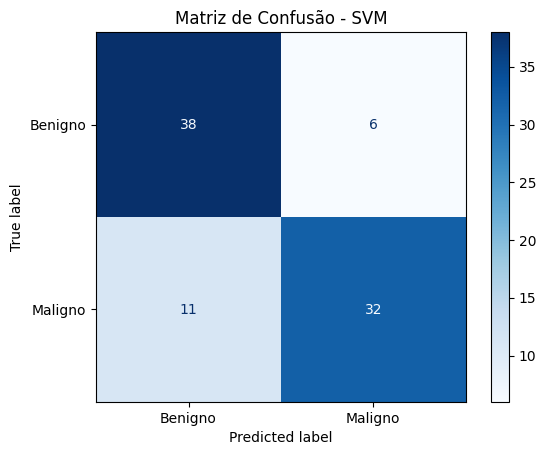

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_svm = svm.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benigno", "Maligno"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de Confusão - SVM")
plt.show()